# Insurance Data — EDA, Cleaning, Preprocessing, Feature Engineering & Extraction

**Dataset:** `insurance.csv`  
**Target:** `charges`  
**Note:** No prediction model is built (as requested). This notebook stops at a clean, model-ready feature set.

**Steps:**
1. Load data
2. EDA (overview + distributions + target analysis)
3. Data cleaning
4. Preprocessing (encoding + scaling)
5. Feature engineering (for `charges`)
6. Feature extraction / selection (for `charges`)
7. Save outputs

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, chi2_contingency

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

CSV_IN = "insurance.csv"
CSV_CLEAN_OUT = "insurance_cleaned.csv"          # cleaned + engineered, original scales
CSV_MODEL_READY_OUT = "insurance_model_ready.csv"  # scaled numerics + encoded, charges untouched
PLOT_DIR = "plots_insurance"
os.makedirs(PLOT_DIR, exist_ok=True)

## 1. Load data

In [2]:
df_raw = pd.read_csv(CSV_IN)

print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
print(df_raw.dtypes)
df_raw.head()

Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


,age,sex,bmi,children,smoker,region,charges
0,19,NaN,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. EDA — descriptive overview

In [3]:
# Numeric + categorical summary
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1337,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [4]:
# Missing values and duplicates
print("Missing values:\n", df_raw.isnull().sum())
print("\nDuplicated rows:", df_raw.duplicated().sum())
df_raw[df_raw.duplicated(keep=False)]  # show the duplicate pair, if any

Missing values:
 age         0
sex         1
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicated rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [5]:
# Categorical levels
for col in ["sex", "smoker", "region"]:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts(dropna=False), "\n")

print("children distribution:")
print(df_raw["children"].value_counts().sort_index())

--- sex ---
sex
male      676
female    661
NaN         1
Name: count, dtype: int64 

--- smoker ---
smoker
no     1064
yes     274
Name: count, dtype: int64 

--- region ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64 

children distribution:
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


In [6]:
# Skew, correlation, sanity checks
print("Skew:\n", df_raw[["age", "bmi", "children", "charges"]].skew())
print("\nNumeric correlation:\n", df_raw.corr(numeric_only=True).round(3))
print("\nSanity checks:")
print(" age < 18:", (df_raw["age"] < 18).sum())
print(" bmi outside [10, 60]:", ((df_raw["bmi"] < 10) | (df_raw["bmi"] > 60)).sum())
print(" charges <= 0:", (df_raw["charges"] <= 0).sum())

Skew:
 age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

Numeric correlation:
             age    bmi  children  charges
age       1.000  0.109     0.042    0.299
bmi       0.109  1.000     0.013    0.198
children  0.042  0.013     1.000    0.068
charges   0.299  0.198     0.068    1.000

Sanity checks:
 age < 18: 0
 bmi outside [10, 60]: 0
 charges <= 0: 0


### 2b. EDA — distributions (histogram + boxplot)

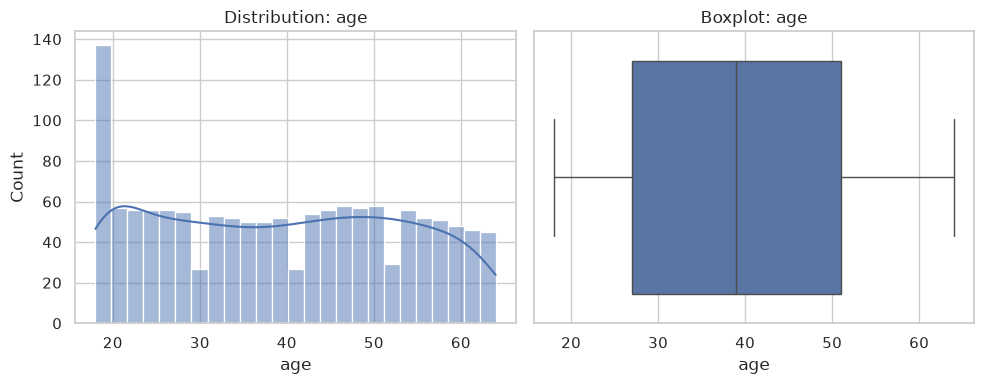

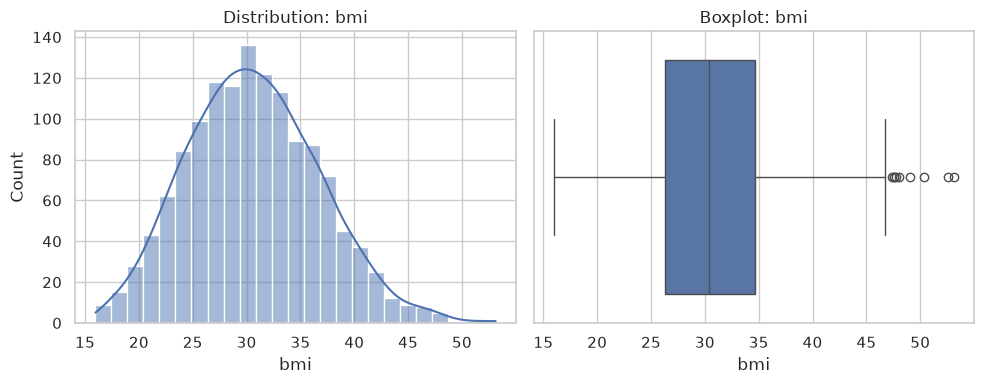

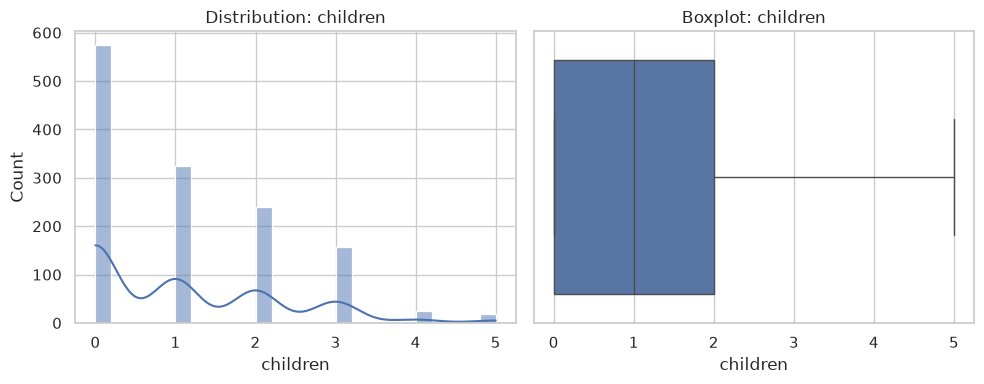

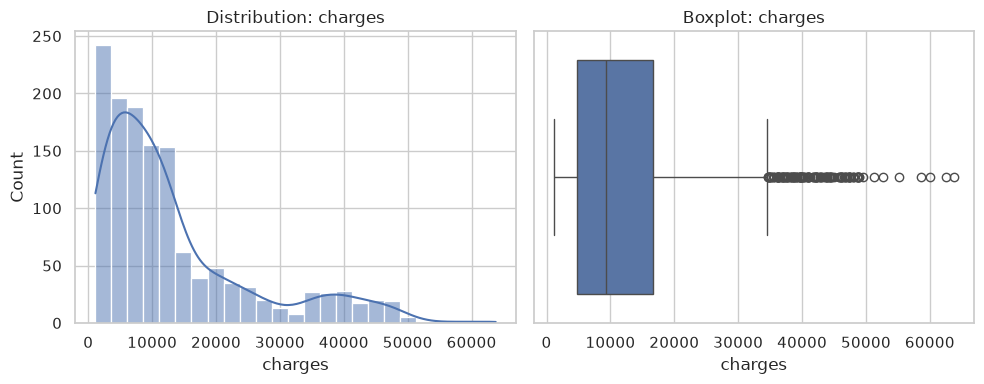

In [7]:
for col in ["age", "bmi", "children", "charges"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(df_raw[col], kde=True, bins=25, ax=axes[0])
    axes[0].set_title(f"Distribution: {col}")
    sns.boxplot(x=df_raw[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    fig.tight_layout()
    fig.savefig(f"{PLOT_DIR}/dist_{col}.png", dpi=120)
    plt.show()

### 2c. EDA — categorical counts

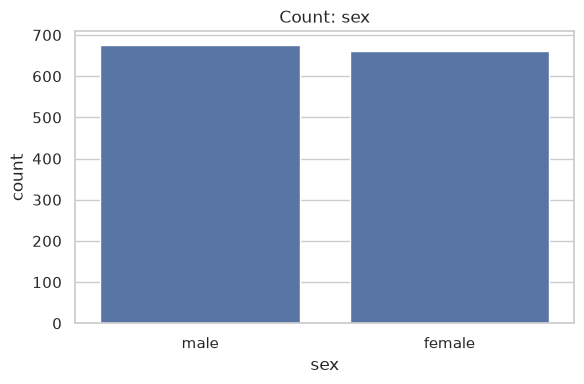

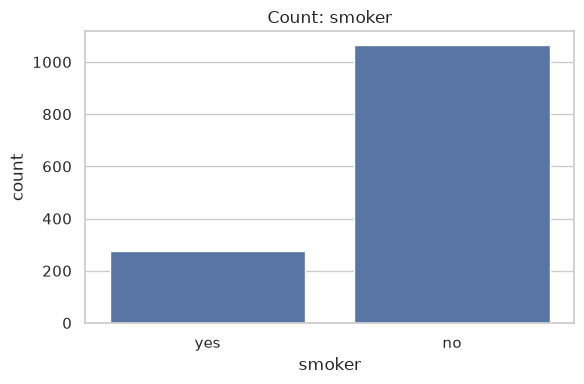

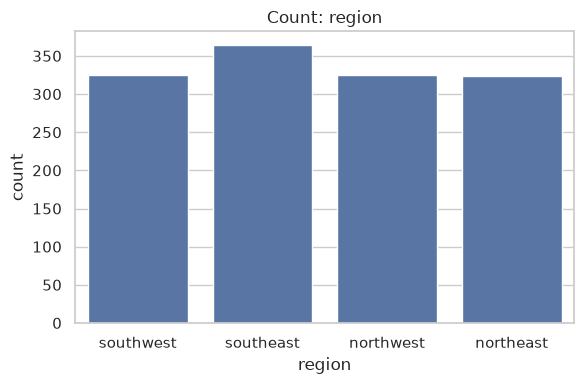

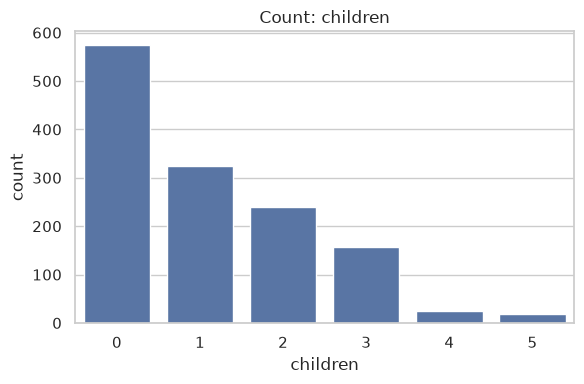

In [8]:
for col in ["sex", "smoker", "region", "children"]:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df_raw[col])
    plt.title(f"Count: {col}")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/count_{col}.png", dpi=120)
    plt.show()

### 2d. EDA — target analysis: what drives `charges`?

In [9]:
# Group means — the main story of this dataset
print("Mean/median charges by smoker:")
print(df_raw.groupby("smoker")["charges"].agg(["count", "mean", "median", "std"]))

print("\nMean/median charges by sex:")
print(df_raw.groupby("sex")["charges"].agg(["count", "mean", "median"]))

print("\nMean/median charges by region:")
print(df_raw.groupby("region")["charges"].agg(["count", "mean", "median"]))

print("\nMean charges: smoker x obese (bmi >= 30):")
print(df_raw.assign(obese=(df_raw["bmi"] >= 30).astype(int))
      .groupby(["smoker", "obese"])["charges"].mean())

Mean/median charges by smoker:
        count          mean       median           std
smoker                                                
no       1064   8434.268298   7345.40530   5993.781819
yes       274  32050.231832  34456.34845  11541.547176

Mean/median charges by sex:
        count          mean      median
sex                                    
female    661  12563.050334  9411.00500
male      676  13956.751178  9369.61575

Mean/median charges by region:
           count          mean        median
region                                      
northeast    324  13406.384516  10057.652025
northwest    325  12417.575374   8965.795750
southeast    364  14735.411438   9294.131950
southwest    325  12346.937377   8798.593000

Mean charges: smoker x obese (bmi >= 30):
smoker  obese
no      0         7977.029520
        1         8842.691548
yes     0        21363.217016
        1        41557.989840
Name: charges, dtype: float64


In [10]:
# IQR outlier flags (informational only — see cleaning step for decision)
for col in ["age", "bmi", "charges"]:
    q1, q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_raw[col] < lo) | (df_raw[col] > hi)).sum()
    print(f"{col}: IQR=[{lo:.2f}, {hi:.2f}]  outliers={n_out}")

age: IQR=[-9.00, 87.00]  outliers=0
bmi: IQR=[13.70, 47.29]  outliers=9
charges: IQR=[-13109.15, 34489.35]  outliers=139


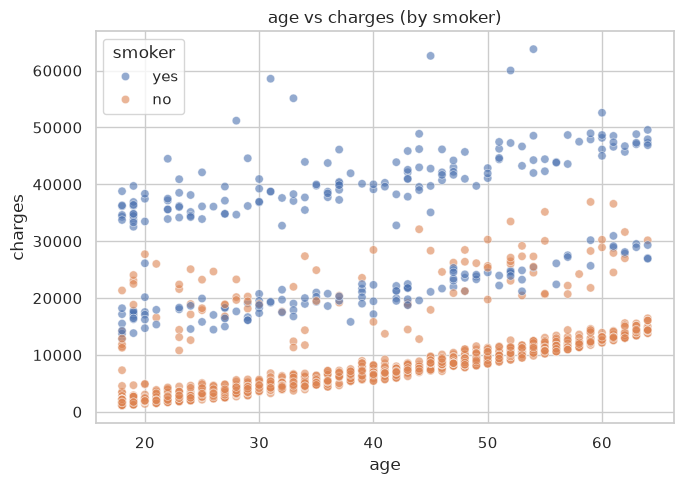

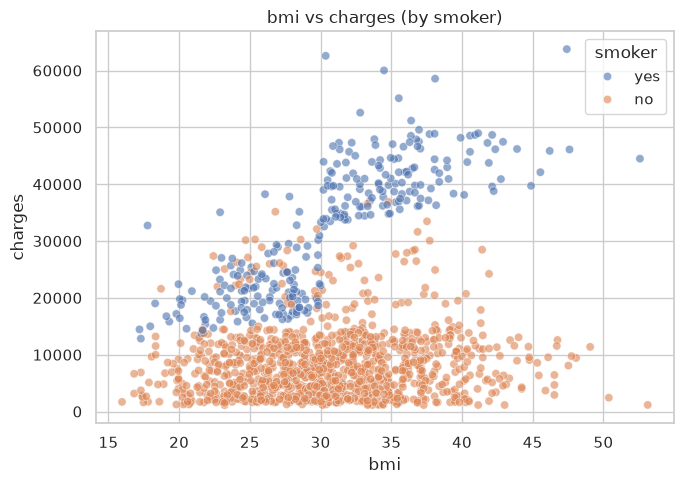

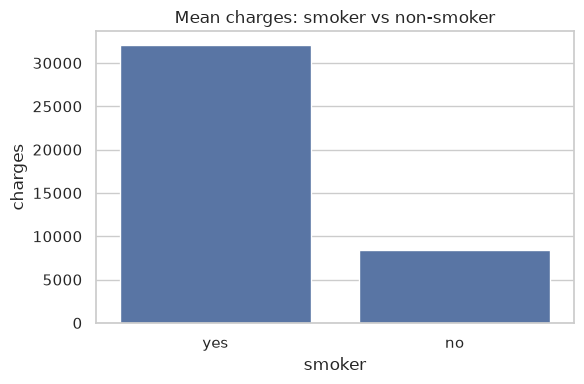

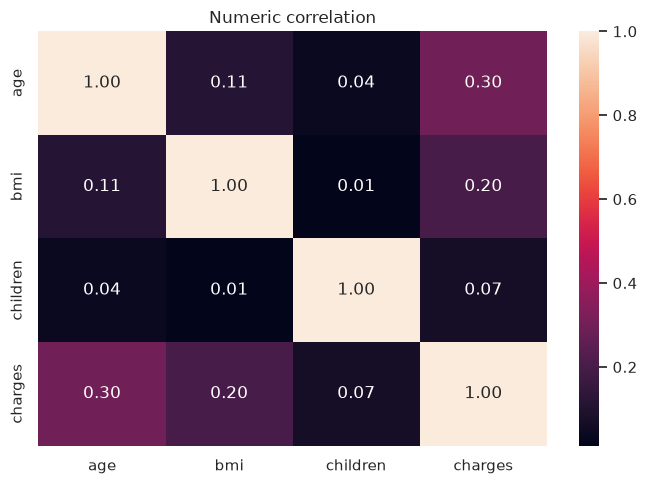

In [11]:
# Scatter: age / bmi vs charges coloured by smoker
for x in ["age", "bmi"]:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df_raw, x=x, y="charges", hue="smoker", alpha=0.6)
    plt.title(f"{x} vs charges (by smoker)")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/scatter_{x}_charges_by_smoker.png", dpi=120)
    plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df_raw, x="smoker", y="charges", estimator="mean", errorbar=None)
plt.title("Mean charges: smoker vs non-smoker")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/bar_smoker_charges.png", dpi=120)
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df_raw.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Numeric correlation")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/corr_heatmap.png", dpi=120)
plt.show()

## 3. Data cleaning

**Issues found:** 1 duplicate row, 1 missing `sex`, 139 high-`charges` values (real smoker signal, kept).

In [12]:
df = df_raw.copy()
print("Start shape:", df.shape)

# 3a. Duplicates — drop one occurrence of the exact duplicate pair
print("Duplicated rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("After drop_duplicates:", df.shape)

Start shape: (1338, 7)
Duplicated rows: 1
After drop_duplicates: (1337, 7)


In [13]:
# 3b. Missing values — only 1 missing (sex). Impute BEFORE encoding using mode.
print(df.isnull().sum())
print(df[df["sex"].isna()])

sex_mode = df["sex"].mode()[0]
print("sex mode =", sex_mode)
df["sex"] = df["sex"].fillna(sex_mode)
print("\nMissing after fix:\n", df.isnull().sum())

age         0
sex         1
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
   age  sex   bmi  children smoker     region    charges
0   19  NaN  27.9         0    yes  southwest  16884.924
sex mode = male

Missing after fix:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [14]:
# 3c. Type / range checks — nothing to coerce in this file
assert df["age"].between(18, 100).all()
assert (df["bmi"] > 0).all() and (df["charges"] > 0).all()
assert set(df["smoker"].unique()) <= {"yes", "no"}
assert set(df["sex"].unique()) <= {"male", "female"}
print("Range checks passed.")

# 3d. Outliers — DECISION: keep all rows.
# 139 high `charges` are real (136/139 are smokers, mean ~32k vs ~8.4k baseline).
# Deleting them would remove the main `charges` signal.
q1, q3 = df["charges"].quantile(0.25), df["charges"].quantile(0.75)
hi = q3 + 1.5 * (q3 - q1)
print(f"charges IQR upper bound: {hi:.2f}")
print("Rows above bound:", (df["charges"] > hi).sum(),
      "| of which smokers:", ((df["charges"] > hi) & (df["smoker"] == "yes").values).sum() if False else ((df["charges"] > hi) & (df["smoker"] == "yes")).sum())

# Diagnostic flag only (dropped before modelling to avoid target leakage)
df["is_high_charges_flag"] = (df["charges"] > hi).astype(int)
print("Cleaned shape:", df.shape)
df.head()

Range checks passed.
charges IQR upper bound: 34524.78
Rows above bound: 139 | of which smokers: 136
Cleaned shape: (1337, 8)


,age,sex,bmi,children,smoker,region,charges,is_high_charges_flag
0,19,male,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


## 4. Preprocessing (encoding + scaling)

`charges` is never scaled or truncated — it stays in original dollars.

In [15]:
# 4a. Binary encode sex / smoker with clear names
df["is_female"] = df["sex"].map({"male": 0, "female": 1})
df["is_smoker"] = df["smoker"].map({"no": 0, "yes": 1})
assert df[["is_female", "is_smoker"]].notnull().all().all()

# 4b. One-hot encode region (drop_first to avoid dummy trap)
df = pd.get_dummies(df, columns=["region"], prefix="region", drop_first=True, dtype=int)
print("Columns:", list(df.columns))
df.head()

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'is_high_charges_flag', 'is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,is_high_charges_flag,is_female,is_smoker,region_northwest,region_southeast,region_southwest
0,19,male,27.900,0,yes,16884.92400,0,0,1,0,0,1
1,18,male,33.770,1,no,1725.55230,0,0,0,0,1,0
2,28,male,33.000,3,no,4449.46200,0,0,0,0,1,0
3,33,male,22.705,0,no,21984.47061,0,0,0,1,0,0
4,32,male,28.880,0,no,3866.85520,0,0,0,1,0,0


In [16]:
# 4c. Scale numeric FEATURES only, on a separate model-ready copy
NUM_TO_SCALE = ["age", "bmi", "children"]
model_ready = df.drop(columns=["is_high_charges_flag"]).copy()
scaler = StandardScaler()
model_ready[NUM_TO_SCALE] = scaler.fit_transform(model_ready[NUM_TO_SCALE])
print(dict(zip(NUM_TO_SCALE, scaler.mean_.round(3))), dict(zip(NUM_TO_SCALE, scaler.scale_.round(3))))
model_ready[NUM_TO_SCALE + ["charges"]].head()

{'age': np.float64(39.222), 'bmi': np.float64(30.663), 'children': np.float64(1.096)} {'age': np.float64(14.039), 'bmi': np.float64(6.098), 'children': np.float64(1.205)}


,age,bmi,children,charges
0,-1.440418,-0.453160,-0.909234,16884.92400
1,-1.511647,0.509422,-0.079442,1725.55230
2,-0.799350,0.383155,1.580143,4449.46200
3,-0.443201,-1.305052,-0.909234,21984.47061
4,-0.514431,-0.292456,-0.909234,3866.85520


## 5. Feature engineering (for `charges`)

Built on the unscaled frame so features stay interpretable. Motivated by EDA: smoker × obese averages ~41.5k vs ~8k baseline.

In [17]:
fe = df.copy()

# 5a. WHO BMI categories
fe["bmi_category"] = pd.cut(fe["bmi"], bins=[0, 18.5, 24.9, 29.9, float("inf")],
                        labels=["Underweight", "Normal", "Overweight", "Obese"])
print(fe["bmi_category"].value_counts())
print(fe.groupby("bmi_category", observed=True)["charges"].mean())

bmi_category
Obese          715
Overweight     380
Normal         221
Underweight     21
Name: count, dtype: int64
bmi_category
Underweight     8657.620652
Normal         10404.900084
Overweight     11006.809989
Obese          15510.915636
Name: charges, dtype: float64


In [18]:
# 5b. Age groups (max age in data is 64, so 3 groups — no empty bin)
fe["age_group"] = pd.cut(fe["age"], bins=[17, 29, 44, 100],
                      labels=["young_18_29", "adult_30_44", "senior_45plus"])
print(fe.groupby("age_group", observed=True)["charges"].mean())

# 5c. Interaction / risk features
fe["is_obese"] = (fe["bmi"] >= 30).astype(int)
fe["is_obese_smoker"] = (fe["is_obese"] & fe["is_smoker"]).astype(int)
fe["smoker_x_bmi"] = fe["bmi"] * fe["is_smoker"]
fe["smoker_x_age"] = fe["age"] * fe["is_smoker"]
fe["age_x_bmi"] = fe["age"] * fe["bmi"]
fe["has_children"] = (fe["children"] > 0).astype(int)
print(fe.groupby("is_obese_smoker")["charges"].mean())
print(fe.groupby("has_children")["charges"].mean())

age_group
young_18_29       9200.619154
adult_30_44      12490.912530
senior_45plus    17070.491773
Name: charges, dtype: float64
is_obese_smoker
0     9839.158474
1    41557.989840
Name: charges, dtype: float64
has_children
0    12384.695344
1    13949.941093
Name: charges, dtype: float64


In [19]:
# One-hot the new nominal categories (drop_first)
fe = pd.get_dummies(fe, columns=["bmi_category", "age_group"], drop_first=True, dtype=int)
print([c for c in fe.columns if "bmi_category" in c or "age_group" in c or "smoker_x" in c or "obese" in c or "has_children" in c])

# Rebuild model-ready table from `fe`: drop raw strings + diagnostic flag (target-derived, never a feature)
DROP_FROM_MODEL = ["sex", "smoker", "bmi_category", "age_group", "is_high_charges_flag", "charges_bin"]
model_ready = fe.drop(columns=[c for c in DROP_FROM_MODEL if c in fe.columns]).copy()
model_ready[["age", "bmi", "children", "smoker_x_bmi", "smoker_x_age", "age_x_bmi"]] = StandardScaler().fit_transform(
    model_ready[["age", "bmi", "children", "smoker_x_bmi", "smoker_x_age", "age_x_bmi"]])
print("model_ready shape:", model_ready.shape)
model_ready.head()

['is_obese', 'is_obese_smoker', 'smoker_x_bmi', 'smoker_x_age', 'has_children', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese', 'age_group_adult_30_44', 'age_group_senior_45plus']
model_ready shape: (1337, 20)


,age,bmi,children,charges,is_female,is_smoker,region_northwest,region_southeast,region_southwest,is_obese,is_obese_smoker,smoker_x_bmi,smoker_x_age,age_x_bmi,has_children,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_group_adult_30_44,age_group_senior_45plus
0,-1.440418,-0.453160,-0.909234,16884.92400,0,1,0,0,1,0,0,1.698613,0.662255,-1.305602,0,0,1,0,0,0
1,-1.511647,0.509422,-0.079442,1725.55230,0,0,0,1,0,1,0,-0.494746,-0.470625,-1.156729,1,0,0,1,0,0
2,-0.799350,0.383155,1.580143,4449.46200,0,0,0,1,0,1,0,-0.494746,-0.470625,-0.551473,1,0,0,1,0,0
3,-0.443201,-1.305052,-0.909234,21984.47061,0,0,1,0,0,0,0,-0.494746,-0.470625,-0.886006,0,1,0,0,1,0
4,-0.514431,-0.292456,-0.909234,3866.85520,0,0,1,0,0,0,0,-0.494746,-0.470625,-0.551166,0,0,1,0,1,0


## 6. Feature extraction / selection for `charges`

No model is trained. We rank features with Pearson correlation (numeric) and chi-square tests (categorical vs `charges` quartile bins).

In [20]:
# 6a. Pearson correlation vs charges
numeric_feats = model_ready.select_dtypes(include=[np.number]).columns.drop("charges")
pearson_df = pd.DataFrame(
    [{"feature": f, "pearson_r": pearsonr(model_ready[f], model_ready["charges"])[0]} for f in numeric_feats]
).sort_values("pearson_r", ascending=False)
pearson_df

,feature,pearson_r
10,smoker_x_bmi,0.845134
9,is_obese_smoker,0.814729
11,smoker_x_age,0.789253
4,is_smoker,0.787234
12,age_x_bmi,0.334184
0,age,0.298308
18,age_group_senior_45plus,0.253410
8,is_obese,0.200347
1,bmi,0.198401
16,bmi_category_Obese,0.197659


In [21]:
# 6b. Chi-square test: categorical features vs binned charges (quartiles).
# is_high_charges_flag is derived FROM charges, so it is excluded (would be leakage).
cat_feats = [c for c in fe.columns
             if c.startswith(("is_", "region_", "bmi_category_", "age_group_"))
             and c != "is_high_charges_flag" and fe[c].nunique() <= 5 and c in model_ready.columns]

fe_binned = fe.copy()
fe_binned["charges_bin"] = pd.qcut(fe_binned["charges"], q=4, labels=False)
rows = []
for col in cat_feats:
    stat, p, _, _ = chi2_contingency(pd.crosstab(fe_binned[col], fe_binned["charges_bin"]))
    rows.append({"feature": col, "chi2": round(stat, 2), "p_value": p, "keep(p<0.05)": p < 0.05})
chi2_df = pd.DataFrame(rows).sort_values("p_value")
chi2_df

,feature,chi2,p_value,keep(p<0.05)
1,is_smoker,848.22,1.507478e-183,True
11,age_group_senior_45plus,574.29,3.773280e-124,True
6,is_obese_smoker,488.40,1.556048e-105,True
10,age_group_adult_30_44,379.77,5.324796e-82,True
3,region_southeast,16.00,1.134966e-03,True
0,is_female,10.73,1.326541e-02,True
5,is_obese,8.52,3.647336e-02,True
9,bmi_category_Obese,7.65,5.371967e-02,False
4,region_southwest,5.09,1.651906e-01,False
7,bmi_category_Normal,4.26,2.343638e-01,False


In [22]:
# 6c. Final selection — transparent rule: keep |r| >= 0.05 OR chi2 p < 0.05, always keep core demographics
STRONG = set(pearson_df.query("pearson_r.abs() >= 0.05")["feature"]) | set(chi2_df.query("`keep(p<0.05)`")["feature"])
CORE = {"age", "bmi", "children", "is_female", "is_smoker"}
selected = [c for c in model_ready.columns if c != "charges" and (c in STRONG or c in CORE)]
print(selected)
final_model_ready = model_ready[selected + ["charges"]]
print("final shape:", final_model_ready.shape)
final_model_ready.head()

['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_southeast', 'is_obese', 'is_obese_smoker', 'smoker_x_bmi', 'smoker_x_age', 'age_x_bmi', 'has_children', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese', 'age_group_adult_30_44', 'age_group_senior_45plus']
final shape: (1337, 18)


,age,bmi,children,is_female,is_smoker,region_southeast,is_obese,is_obese_smoker,smoker_x_bmi,smoker_x_age,age_x_bmi,has_children,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_group_adult_30_44,age_group_senior_45plus,charges
0,-1.440418,-0.453160,-0.909234,0,1,0,0,0,1.698613,0.662255,-1.305602,0,0,1,0,0,0,16884.92400
1,-1.511647,0.509422,-0.079442,0,0,1,1,0,-0.494746,-0.470625,-1.156729,1,0,0,1,0,0,1725.55230
2,-0.799350,0.383155,1.580143,0,0,1,1,0,-0.494746,-0.470625,-0.551473,1,0,0,1,0,0,4449.46200
3,-0.443201,-1.305052,-0.909234,0,0,0,0,0,-0.494746,-0.470625,-0.886006,0,1,0,0,1,0,21984.47061
4,-0.514431,-0.292456,-0.909234,0,0,0,0,0,-0.494746,-0.470625,-0.551166,0,0,1,0,1,0,3866.85520


## 7. Save outputs

In [23]:
clean_save = fe.drop(columns=[c for c in ["is_high_charges_flag", "charges_bin"] if c in fe.columns])
clean_save.to_csv(CSV_CLEAN_OUT, index=False)
final_model_ready.to_csv(CSV_MODEL_READY_OUT, index=False)
print(f"Saved: {CSV_CLEAN_OUT} {clean_save.shape}")
print(f"Saved: {CSV_MODEL_READY_OUT} {final_model_ready.shape}")
print(f"Plots: ./{PLOT_DIR}/")

Saved: insurance_cleaned.csv (1337, 22)
Saved: insurance_model_ready.csv (1337, 18)
Plots: ./plots_insurance/


## Summary

- **Cleaned:** 1338 → 1337 rows (1 duplicate removed), 1 missing `sex` filled with mode before encoding.
- **Kept outliers:** 139 high `charges` are real smoker signal, not errors.
- **`charges` untouched:** never scaled or truncated (old `astype(int)` bug fixed).
- **Top signals for `charges`:** `smoker_x_bmi` (r=0.85), `is_obese_smoker` (r=0.81), `is_smoker` (r=0.79).
- **Next step (not done here):** train/test split + regression model.